<h1 style="color:lightblue;">Disease–Symptom Dataset – Simple EDA</h1>

- Each **row** represents a patient.
- Each **column (except the target)** represents a symptom (0 = absent, 1 = present).
- The **target column** (`diseases`) contains the diagnosed disease.

- **Row count per disease** relates to how common it is in the real world  
- Multiple different sets of symptoms may point to the same disease  
- A single symptom might strongly indicate a disease — suggesting **high correlation**  
- A row with just **one symptom** isn't an error — it's just a very significant one  

<h4 style="color:lightblue;">The dataset helps us explore how symptom combinations can predict diseases and is great for tasks like:</h4>

- Class balancing  
- Feature selection  
- Multiclass classification  

<h2 style="color:cyan;">1. Load the Dataset</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("Disease and symptoms dataset.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (246945, 378)


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


<h2 style="color:cyan;">2. Dataset Information</h2> <h4>Basic structure: column types, missing values, and memory usage.</h4>

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


<h2 style="color:cyan;">3. Dataset Statistics</h2> <h4>Summary statistics for numerical columns.</h4>

In [5]:
df.describe()


,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
count,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,...,246945.0,246945.0,246945.0,246945.0,246945.000000,246945.0,246945.0,246945.0,246945.000000,246945.0
mean,0.039235,0.042746,0.086440,0.061001,0.097252,0.069943,0.039410,0.040572,0.037871,0.024876,...,0.0,0.0,0.0,0.0,0.001385,0.0,0.0,0.0,0.000073,0.0
std,0.194155,0.202285,0.281014,0.239333,0.296302,0.255051,0.194568,0.197296,0.190884,0.155747,...,0.0,0.0,0.0,0.0,0.037189,0.0,0.0,0.0,0.008537,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0


<h2 style="color:cyan;">4. Identify Target and Feature Columns</h2> <h4>Separating the disease label from symptom features.</h4>

In [6]:
target = "diseases"
features = [c for c in df.columns if c != target]

print("Target:", target)
print("Number of features:", len(features))
features[:20]


Target: diseases
Number of features: 377


['anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat']

<h2 style="color:cyan;">5. Missing Value Check</h2> <h4>Ensuring symptoms contain valid binary values only (0 or 1).</h4>

In [7]:
df.isnull().sum()


diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [8]:
for c in features:
    vals = set(df[c].unique())
    if not vals.issubset({0, 1}):
        print("Non-binary:", c, vals)


<h2 style="color:cyan;">6. Unique Disease Count</h2> <h4>Showing how many distinct diseases exist in the dataset.</h4>

In [9]:
d_counts = df[target].value_counts()
print("Unique diseases:", len(d_counts))
d_counts.head(10)


Unique diseases: 773


diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
vaginal cyst                      1215
esophagitis                       1215
peripheral nerve disorder         1215
hypoglycemia                      1215
conjunctivitis due to allergy     1215
Name: count, dtype: int64

<h2 style="color:cyan;">7. Visualizing Top Disease Frequencies</h2> <h4>Bar plot of the top 20 most common diseases.</h4>

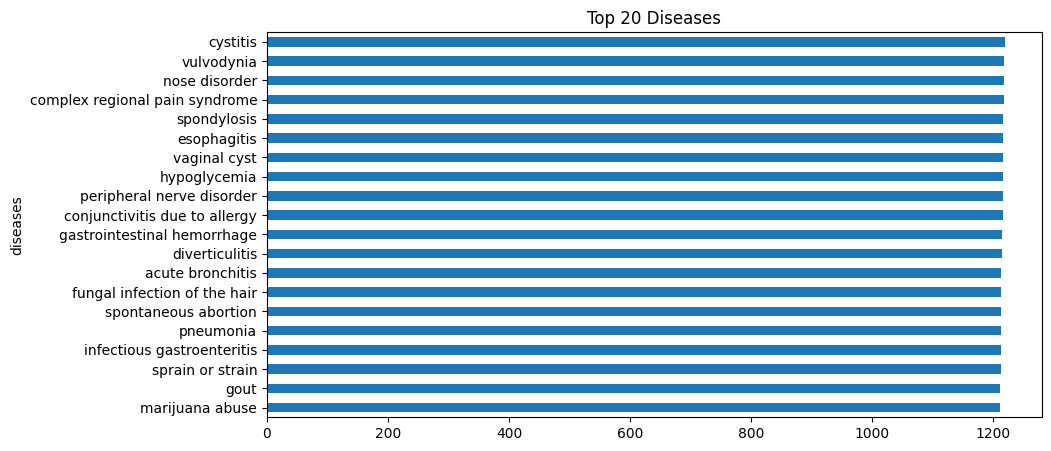

In [10]:
plt.figure(figsize=(10,5))
d_counts.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Diseases")
plt.show()


<h2 style="color:cyan;">8. Checking Dataset Sparsity</h2> <h4>Measuring zeros, ones, and average symptom count per patient.</h4>

In [11]:
X = df[features]

total = X.size
zeros = (X == 0).sum().sum()
ones = (X == 1).sum().sum()

print("Zeros:", zeros, f"({zeros/total:.2%})")
print("Ones:", ones, f"({ones/total:.2%})")

sym_count = X.sum(axis=1)
print("Avg symptoms:", sym_count.mean())
print("Min:", sym_count.min())
print("Max:", sym_count.max())


Zeros: 91781344 (98.59%)
Ones: 1316921 (1.41%)
Avg symptoms: 5.3328514446536674
Min: 1
Max: 12


<h2 style="color:cyan;">9. Sparse Heatmap</h2> <h4>Visualizing the 60 most variable symptoms across random patients.</h4>

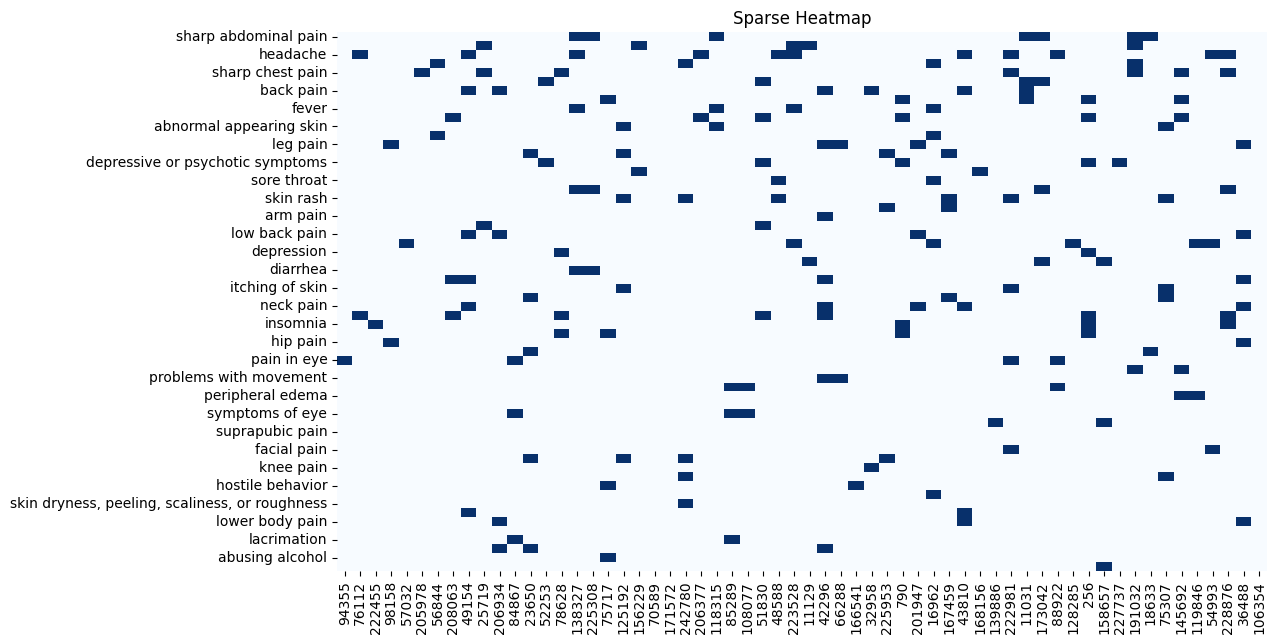

In [12]:
sample = X.sample(60, random_state=42)
top60 = X.var().sort_values(ascending=False).head(60).index

plt.figure(figsize=(12,7))
sns.heatmap(sample[top60].T, cmap="Blues", cbar=False)
plt.title("Sparse Heatmap")
plt.show()


<h2 style="color:cyan;">10. Most Common Symptoms</h2> <h4>Frequency of symptoms across the dataset (percentage occurrence).</h4>

In [13]:
sym_freq = (X.mean() * 100).sort_values(ascending=False)
sym_freq.head(10)


sharp abdominal pain    13.082670
vomiting                11.287534
headache                10.009921
cough                    9.838628
sharp chest pain         9.725242
nausea                   9.592014
back pain                8.831521
shortness of breath      8.644030
fever                    8.258519
dizziness                6.994270
dtype: float64

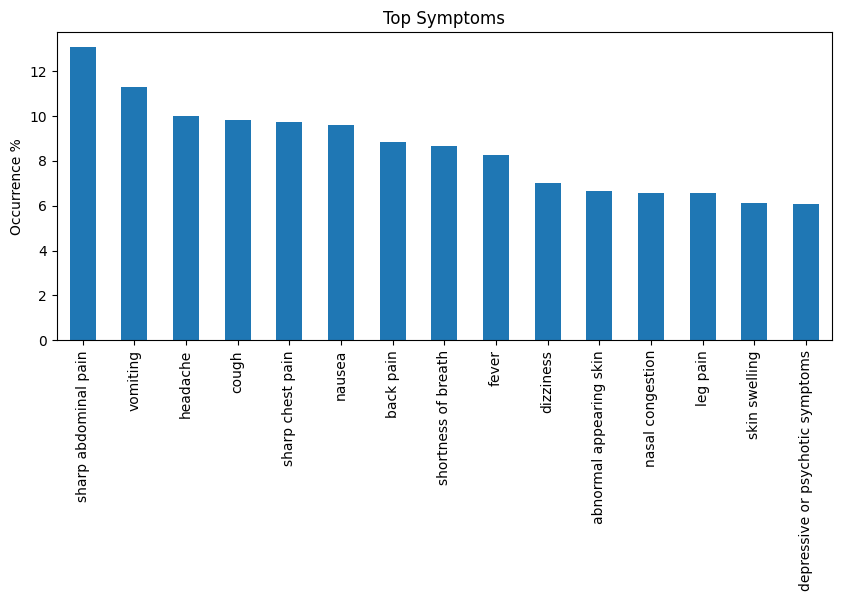

In [14]:
plt.figure(figsize=(10,4))
sym_freq.head(15).plot(kind='bar')
plt.title("Top Symptoms")
plt.ylabel("Occurrence %")
plt.show()


<h2 style="color:cyan;">11. Symptom Correlation (Top 10)</h2> <h4>Heatmap showing relationships between the 10 most frequent symptoms.</h4>

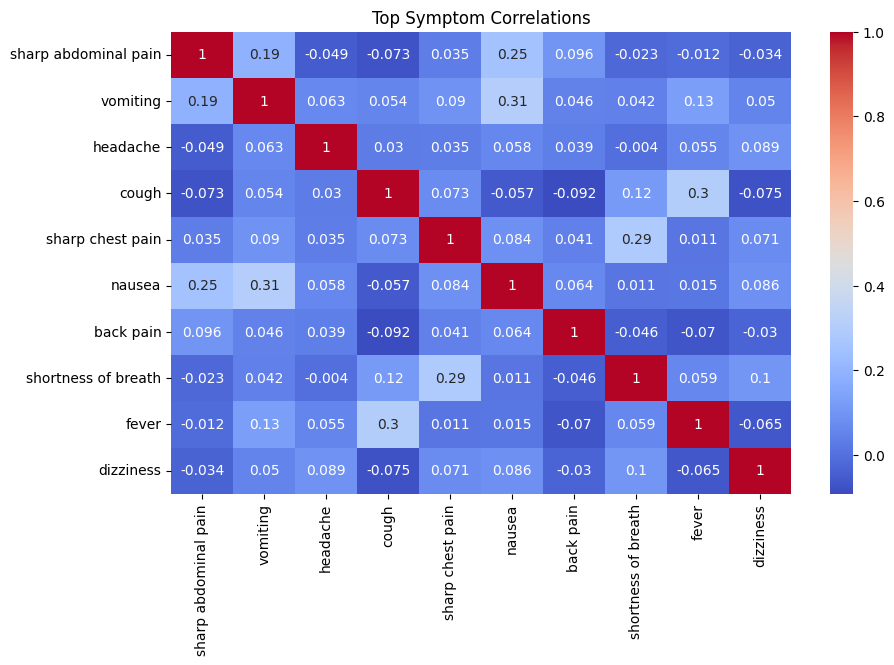

In [15]:
top10 = sym_freq.head(10).index
corr = df[top10].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Top Symptom Correlations")
plt.show()


The heatmap above shows the correlation between the **top 10 most frequent symptoms**.
 Most symptom pairs have **very low correlation** (close to 0)  
- Only a few combinations show mild co-occurrence:
  - **Vomiting + Nausea (0.31)**
  - **Fever + Cough (0.30)**
  - **Shortness of Breath + Sharp Chest Pain (0.29)**
- No strong negative correlations exist — symptoms do not exclude each other
- This confirms that the dataset behaves like a **true sparse medical dataset**, where:
  - Symptoms rarely appear in clusters
  - A **single symptom may still strongly predict a disease**

<h2 style="color:cyan;">12. Common vs Rare Diseases</h2> <h4>Diseases are split into common and rare based on a frequency threshold.</h4>

In [16]:
threshold = 10
common = d_counts[d_counts >= threshold]
rare   = d_counts[d_counts < threshold]

print("Common diseases:", len(common))
print("Rare diseases:", len(rare))


Common diseases: 677
Rare diseases: 96


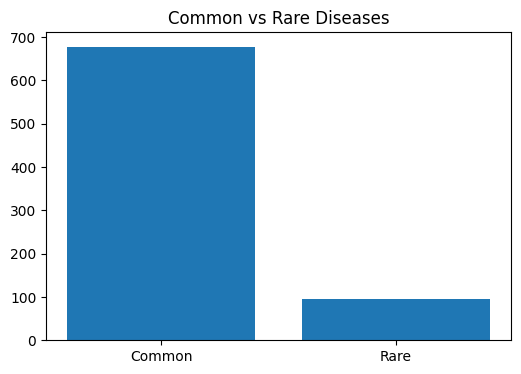

In [17]:
plt.figure(figsize=(6,4))
plt.bar(["Common", "Rare"], [len(common), len(rare)])
plt.title("Common vs Rare Diseases")
plt.show()


<h2 style="color:cyan;">13. Grouping Rare Diseases</h2> <h4>Rare diseases (frequency < 10) are merged into a single 'others' class.</h4>

In [18]:
df["disease_group"] = df[target].apply(
    lambda x: "others" if x in rare.index else x
)

print("Unique after grouping:", df["disease_group"].nunique())


Unique after grouping: 678


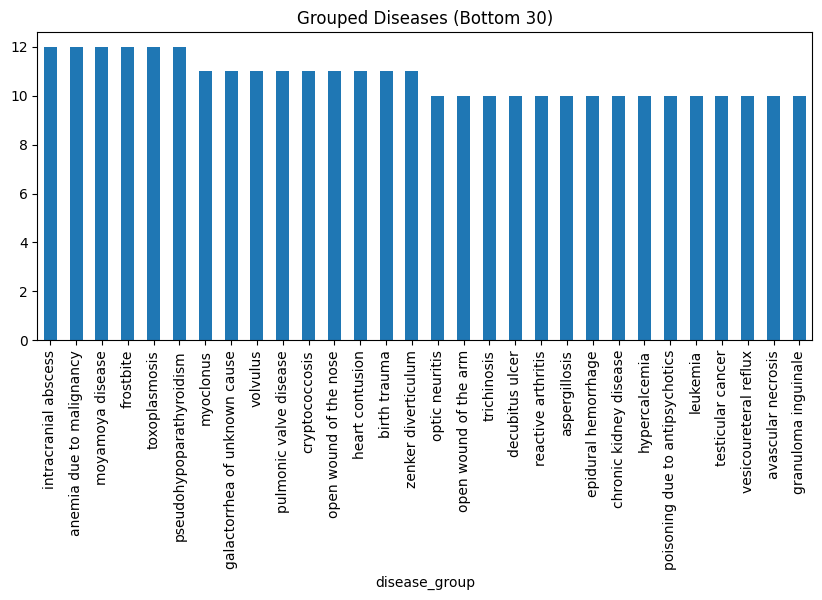

In [19]:
plt.figure(figsize=(10,4))
df["disease_group"].value_counts().tail(30).plot(kind="bar")
plt.title("Grouped Diseases (Bottom 30)")
plt.show()


In [ ]:

from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import LabelEncoder


<h2 style="color:cyan;">14. Train-Test Split</h2> <h4>Stratified splitting ensures disease distribution remains consistent.</h4>

In [21]:

X = df.drop(["diseases", "disease_group"], axis=1)
le = LabelEncoder()
y = le.fit_transform(df["disease_group"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (197556, 377) Test: (49389, 377)


<h2 style="color:cyan;">15. Undersampling Major Classes</h2> <h4>Large classes are limited to 250 samples to reduce imbalance.</h4>

In [23]:
from imblearn.under_sampling import RandomUnderSampler

train_counts = Counter(y_train)
undersample_max = 250

strategy = {
    cls: min(cnt, undersample_max) for cls, cnt in train_counts.items()
}

rus = RandomUnderSampler(sampling_strategy=strategy, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("After undersample:", X_train_res.shape)

After undersample: (105450, 377)


<h2 style="color:cyan;">16. Model Training (Best Parameters)</h2> <h4>Training BernoulliNB, Logistic Regression, and LinearSVC with tuned hyperparameters.</h4>

In [ ]:

from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

best_nb = BernoulliNB(alpha=0.0001472526647137094)
best_nb.fit(X_train_res, y_train_res)

best_lr = LogisticRegression(
    penalty="l2",
    C=0.1286770389556086,
    solver="lbfgs",
    max_iter=1500,
    n_jobs=-1
)
best_lr.fit(X_train_res, y_train_res)

svc = LinearSVC(
    C=0.2004369995737748,
    max_iter=2000,
    random_state=42
)
svc.fit(X_train_res, y_train_res)

best_svc = CalibratedClassifierCV(svc, cv="prefit")
best_svc.fit(X_train_res, y_train_res)

,estimator,LinearSVC(C=0...ndom_state=42)
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.2004369995737748
,multi_class,'ovr'


<h2 style="color:cyan;">17. Individual Model Evaluation</h2> <h4>Accuracy, Balanced Accuracy, Macro F1, and Weighted F1 for each classifier.</h4>

In [25]:

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score

def eval_model(model, name):
    preds = model.predict(X_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
        "weighted_f1": f1_score(y_test, preds, average="weighted")
    }

print(eval_model(best_nb, "BernoulliNB"))
print(eval_model(best_lr, "LogisticReg"))
print(eval_model(best_svc, "LinearSVC"))

{'model': 'BernoulliNB', 'accuracy': 0.8721172730770009, 'balanced_accuracy': 0.905880561239341, 'macro_f1': 0.8700418507611547, 'weighted_f1': 0.8737256449279364}
{'model': 'LogisticReg', 'accuracy': 0.8632286541537589, 'balanced_accuracy': 0.7647108380602361, 'macro_f1': 0.7590812427661655, 'weighted_f1': 0.8617256276707903}
{'model': 'LinearSVC', 'accuracy': 0.8619125716252607, 'balanced_accuracy': 0.8846882752329839, 'macro_f1': 0.8611083070510055, 'weighted_f1': 0.862396583035355}


<h2 style="color:cyan;">18. Ensemble Evaluation</h2> <h4>Combining model probabilities for improved stability and accuracy.</h4>

In [26]:

def get_proba(m, X):
    if hasattr(m, "predict_proba"):
        return m.predict_proba(X)
    s = m.decision_function(X)
    e = np.exp(s - np.max(s, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

p_nb = get_proba(best_nb, X_test)
p_lr = get_proba(best_lr, X_test)
p_svc = get_proba(best_svc, X_test)

p_ensemble = (p_nb + p_lr + p_svc) / 3
pred_ens = np.argmax(p_ensemble, axis=1)

print("Ensemble Accuracy:", accuracy_score(y_test, pred_ens))
print("Ensemble Balanced Acc:", balanced_accuracy_score(y_test, pred_ens))
print("Ensemble Macro F1:", f1_score(y_test, pred_ens, average="macro"))
print("Ensemble Weighted F1:", f1_score(y_test, pred_ens, average="weighted"))
print("Ensemble Top-3:", top_k_accuracy_score(y_test, p_ensemble, k=3))


Ensemble Accuracy: 0.8703759946546802
Ensemble Balanced Acc: 0.8985926412507974
Ensemble Macro F1: 0.8723130388292757
Ensemble Weighted F1: 0.8712805485366314
Ensemble Top-3: 0.9632509263196258


<h2 style="color:cyan;">19. Loading Symptoms for NLP</h2> <h4>Preparing clean symptom names and generating embeddings.</h4>

In [ ]:
from sentence_transformers import SentenceTransformer
from rapidfuzz import fuzz, process

df = pd.read_csv("Disease and symptoms dataset.csv")

SYMPTOM_COLS = [c for c in df.columns if c != "diseases"]
SYMPTOM_COLS_CLEAN = [
    c.lower().strip().replace(" ", "_")
    .replace("-", "_")
    .replace("/", "_")
    for c in SYMPTOM_COLS
]

SYMPTOM_TEXTS = [s.replace("_", " ") for s in SYMPTOM_COLS_CLEAN]

print(f"Loaded {len(SYMPTOM_COLS_CLEAN)} symptoms.")
print("Loading embeddings...")
model = SentenceTransformer("all-MiniLM-L6-v2")

symptom_embeddings = model.encode(
    SYMPTOM_TEXTS, normalize_embeddings=True, convert_to_numpy=True
)

print("NLP system ready.\n")
def preprocess_text(text):
    text = text.lower().strip()

    for p in [";", ",", ".", ":", "/", "\\"]:
        text = text.replace(p, " ")

    splitters = [" and ", " with ", " but ", " also "]

    parts = [text]
    for s in splitters:
        new_parts = []
        for p in parts:
            new_parts.extend(p.split(s))
        parts = new_parts

    parts = [p.strip() for p in parts if p.strip()]
    return parts


def nlp_match(user_text, sim_threshold=0.45, fuzzy_min=70):
    fragments = preprocess_text(user_text)
    semantic_candidates = []

    for frag in fragments:
        user_emb = model.encode(
            frag, normalize_embeddings=True, convert_to_numpy=True
        )
        
        sims = np.dot(symptom_embeddings, user_emb)

        for idx, sc in enumerate(sims):
            if sc >= sim_threshold:
                semantic_candidates.append(
                    (SYMPTOM_COLS_CLEAN[idx], float(sc))
                )

    sem_dict = {}
    for sym, sc in semantic_candidates:
        if sym not in sem_dict or sc > sem_dict[sym]:
            sem_dict[sym] = sc

    semantic_final = sorted(sem_dict.items(), key=lambda x: -x[1])

    if semantic_final:
        return semantic_final[:10], "semantic"

    # otherwise fuzzy fallback
    fuzzy_raw = process.extract(
        user_text,
        SYMPTOM_COLS_CLEAN,
        scorer=fuzz.WRatio
    )

    fuzzy_final = [
        (sym, score/100)
        for sym, score, _ in fuzzy_raw
        if score >= fuzzy_min
    ]

    fuzzy_final = sorted(fuzzy_final, key=lambda x: -x[1])
    return fuzzy_final[:10], "fuzzy"




Loaded 377 symptoms.
Loading embeddings...
NLP system ready.



<h2 style="color:cyan;">20. NLP Text Preprocessing</h2> <h4>Cleaning user input and splitting into meaningful symptom fragments.</h4>

In [ ]:
ML_COLS = list(X.columns)
ML_COLS_CLEAN = [
    c.lower().strip().replace(" ", "_").replace("-", "_").replace("/", "_")
    for c in ML_COLS
]

SYMPTOM_TO_INDEX = {s: i for i, s in enumerate(ML_COLS_CLEAN)}
NUM_SYMPTOMS = len(ML_COLS_CLEAN)

def symptoms_to_vector(symptom_names):
    vec = np.zeros(NUM_SYMPTOMS, dtype=int)
    for s in symptom_names:
        if s in SYMPTOM_TO_INDEX:
            vec[SYMPTOM_TO_INDEX[s]] = 1
    return vec



<h2 style="color:cyan;">21. NLP-based Disease Prediction</h2> <h4>Using top 3 matched symptoms to generate top 3 disease predictions.</h4>

In [ ]:
def nlp_predict_disease(user_text):
    matches, mode = nlp_match(user_text)
    if not matches:
        return None, None, None, []

    top3_symptoms = [m[0] for m in matches[:3]]

    vec = symptoms_to_vector(top3_symptoms).reshape(1, -1)

    p_nb = get_proba(best_nb, vec)
    p_lr = get_proba(best_lr, vec)
    p_svc = get_proba(best_svc, vec)
    p = (p_nb + p_lr + p_svc) / 3

    idx = np.argsort(-p[0])[:3]
    diseases = le.inverse_transform(idx)

    return diseases, top3_symptoms, p[0][idx], mode


<h2 style="color:cyan;">22. NLP Prediction Example</h2> <h4>Demonstration of input, matched symptoms, and predicted diseases.</h4>

In [30]:
text = "severe headache with vomiting"
diseases, symptoms, scores, mode = nlp_predict_disease(text)

print("\nINPUT:", text)
print("NLP mode:", mode)
print("Matched symptoms:", symptoms)
print("\nTop-3 predicted diseases:")
for d, s in zip(diseases, scores):
    print(f"{d:30s}  | score={s:.3f}")



INPUT: severe headache with vomiting
NLP mode: semantic
Matched symptoms: ['vomiting', 'headache', 'nausea']

Top-3 predicted diseases:
meningitis                      | score=0.120
headache after lumbar puncture  | score=0.100
problem during pregnancy        | score=0.088
